#Introducción al aprendizaje por refuerzo

Aprender y adaptarse a las nuevas circunstancias es un proceso crucial para los humanos y, en general, para todos los animales. Por lo general, el aprendizaje se entiende como un proceso de prueba y error a través del cual mejoramos nuestro desempeño en tareas particulares. Nuestra vida es un proceso de aprendizaje continuo, es decir, partimos de metas simples (por ejemplo, caminar), y terminamos persiguiendo tareas difíciles y complejas (por ejemplo, practicar un deporte). Como humanos, siempre nos impulsa nuestro mecanismo de recompensa, que premia los buenos comportamientos y castiga los malos.

El aprendizaje por refuerzo ( RL ), inspirado en el proceso de aprendizaje humano, es un subcampo del aprendizaje automático y se ocupa del aprendizaje a partir de la interacción. Con el término "interacción" nos referimos al proceso de prueba y error a través del cual nosotros, como humanos, comprendemos las consecuencias de nuestras acciones y construimos nuestras propias experiencias.

RL, en particular, considera problemas de toma de decisiones secuenciales. Estos son problemas en los que un agente tiene que tomar una secuencia de decisiones, es decir, acciones, para maximizar una determinada medida de desempeño.

RL considera que las tareas son procesos de decisión de Markov ( MDP )), que son problemas que surgen en muchos escenarios del mundo real. En este escenario, el tomador de decisiones, denominado agente, tiene que tomar decisiones teniendo en cuenta la experiencia y la incertidumbre del entorno. Los agentes están dirigidos a objetivos; solo necesitan una noción de un objetivo, como una señal numérica, para ser maximizados. A diferencia del aprendizaje supervisado, en RL no es necesario proporcionar buenos ejemplos; es el agente quien aprende a convertir las situaciones en acciones. El mapeo de situaciones (estados) a acciones se denomina "política" en la literatura y representa el comportamiento o la estrategia del agente. Resolver un MDP significa encontrar la política del agente maximizando el resultado deseado (es decir, la recompensa total). Estudiaremos los MDP con más detalle en capítulos futuros.

RL se ha aplicado con éxito a varios tipos de problemas y dominios, mostrando resultados interesantes. Este capítulo es una introducción a la RL. Su objetivo es explicar algunas aplicaciones y describir conceptos tanto desde una perspectiva intuitiva como desde un punto de vista matemático. Ambos aspectos son muy importantes a la hora de aprender nuevas disciplinas. Sin una comprensión intuitiva, es imposible dar sentido a fórmulas y algoritmos; sin antecedentes matemáticos, es difícil implementar algoritmos nuevos o existentes.

# Optimización en rutas de transporte


**1.   Problema**

El problema a resolver será el de optimizar los caminos o rutas en un plano. El plano muestra los diferentes sitios y calles por donde se puede transitar. Para efectos de simplificar el problema, vamos a utilizar sólo 12 ubicaciones a los que se puede desplazar y los caminos que o calles por donde se puede mover un transporte. El objetivo del problema es de realizar un programa computacional ayudado de la inteligencia artificial (porblema que resolveremos inicialmente con el algortimo Q-Learning) que en cada momento que se solicite, arroje la ruta óptima para ir desde un punto inicial a uno final, con posibles restricciones o imposisciones de paso por algún lugar.


**2.   Caso de estudio**

A medida que los clientes hacen los pedidos online, un sistema de transporte evalua constantemente la mejor ruta para realizar los desplazamientos y así surtir o recoger productos de los diferentes locales que lo solicitan. Así es como se ve:

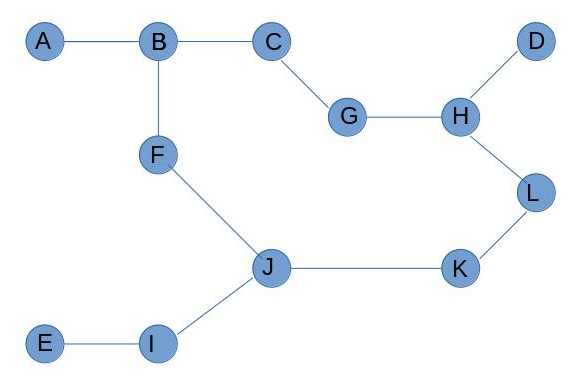

Las 12 ubicaciones están conectadas a un sistema informático, que clasifica en tiempo real las prioridades de recolección de productos para estas 12  ubicaciones. Por ejemplo, en un momento específico t, devolverá la siguiente clasificación:


La ubicación G por ejemplo podemos asignarle la prioridad 1, lo que significa que es la máxima prioridad, ya que contiene un producto que debe recogerse y/o entregarse de inmediato. Nuestro transportador debe moverse a la ubicación G por la ruta más corta, dependiendo de dónde se encuentre. El objetivo entonces es construir un sistema inteligente que regrese esa ruta más corta, donde sea que se encuentre el transporte. Pero luego, como vemos, las ubicaciones K y L podrían estar en las 3 prioridades principales. Por lo tanto, deberíamos implementar una opción para que nuestro sistema de transporte pase por algunas ubicaciones intermedias antes de llegar a su ubicación final de máxima prioridad.

La forma en que el sistema calcula las prioridades de las ubicaciones está fuera del alcance de este caso práctico. La razón de esto es que puede haber muchas formas, desde reglas o algoritmos simples, hasta cálculos deterministas y aprendizaje automático. Pero la mayoría de estas formas no serían inteligencia artificial como la conocemos hoy. En lo que realmente queremos centrarnos es en el sistema inteligente central, que abarca Q-Learning, Deep Q-Learning y otras ramas de Reinforcement Learning. Entonces, solo diremos, por ejemplo, que la ubicación G es la máxima prioridad porque uno de los clientes de "platino" u "oro" que por ejemplo son los más leales de la compañía hicieron un pedido urgente de un producto almacenado en la ubicación G, que por lo tanto debe entregarse lo antes posible.

**2.1 Ambiente a definir**

Al construir un sistema inteligente, lo primero que siempre tenemos que hacer es definir el ambiente. Y definir un ambiente siempre requiere los tres elementos siguientes:

Definir los estados
Definir las acciones
Definir las recompensas

Definamos estos tres elementos, uno por uno.

**2.1.1 Definición de estados**

El estado de entrada es simplemente la ubicación donde está nuestro sistema de transporte en cada momento t, es decir se asociará a cada estado (un lugar por ejemplo A,B,C,D ...) un número:



In [11]:
# Importar las librerías
import numpy as np

# Definición de los estados
def_de_estados = {'A': 0,
                  'B': 1,
                  'C': 2,
                  'D': 3,
                  'E': 4,
                  'F': 5,
                  'G': 6,
                  'H': 7,
                  'I': 8,
                  'J': 9,
                  'K': 10,
                  'L': 11}
print(def_de_estados)


{'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'J': 9, 'K': 10, 'L': 11}



**2.1.2 Definición de las acciones**

Las acciones son simplemente los siguientes movimientos que el sistema de transporte puede hacer para ir de un lugar a otro. Entonces, por ejemplo, digamos que un carro está en la ubicación J, las posibles acciones que el carro puede llevar a cabo es ir a I, F o K. Ahora, desde un punto de vista genérico, las acciones serán el vector completo donde un carro puede ir, así, las acciones corresponderan a los mismos estados.

In [12]:
# Definición de las acciones
acciones = [0,1,2,3,4,5,6,7,8,9,10,11]
print(acciones)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]


**2.1.3 Definición de las recompensas**

Lo último que tenemos que hacer ahora para construir nuestro entorno es definir un sistema de recompensas. Más específicamente, tenemos que definir una función de recompensa $R$ que toma como entradas un estado $s$ y una acción $a$, y devuelve una recompensa numérica que el sistema inteligente obtendrá al llevar a cabo la acción $a$ en el estado $s$:

$R:(estado,acción) → r \in \mathbb R $

Dado que hay un número discreto y finito de estados (los índices de 0 a 11), así como un número discreto y finito de acciones (mismos índices de 0 a 11), la mejor manera de construir nuestra función de recompensa $R$ es simplemente hacer una matriz. Nuestra función de recompensa será exactamente una matriz de 12 filas y 12 columnas, donde las filas corresponden a los estados y las columnas corresponden a las acciones. De esa forma, en nuestra función $R:(estado,acción) → r \in \mathbb R $, estado es $e$ y serán las filas y acción es $a$ y serán las columnas.

$R_{e,a} =
 \begin{pmatrix}
  a_{1,1} & a_{1,2} & \cdots & a_{1,n} \\
  a_{2,1} & a_{2,2} & \cdots & a_{2,n} \\
  \vdots  & \vdots  & \ddots & \vdots  \\
  a_{m,1} & a_{m,2} & \cdots & a_{m,n}
 \end{pmatrix}$

 *Ubicación A.*

Cuando se encuentra en la ubicación A, eltransporte solo puede ir a la ubicación B. Por lo tanto, dado que la ubicación A tiene el índice 0 (primera fila de la matriz) y la ubicación B tiene el índice 1 (segunda columna de la matriz), la primera fila de la matriz de las recompensas obtendrá un 1 en la segunda columna y un 0 en todas las otras columnas.

*Ubicación B.*

Al estar en la ubicación B, el transporte solo puede ir a tres ubicaciones diferentes: A, C y F. Dado que B tiene el índice 1 (segunda fila), y A, C, F tienen los índices respectivos 0, 2, 5 (1ra, 3ra. , y sexta columna), entonces la segunda fila de la matriz de recompensas obtendrá un 1 en las columnas 1a, 3a y 6a, y 0 en todas las otras columnas.

**Tarea 1**

1. Llenar completamente la matriz $R_{e,a}$ para los posibles caminos en cada estado del carro, colocando un 1 en camino posible y 0 en el caso de no poder desplazarce a esa celda.  
2. Ampliar el sistema de estados a 16 lugares y definan cada grupo su propio camino. El objetivo es que cada grupo irá construyendo su propio sistema de rutas.
3. El reporte final se debe subir al classroom de la materia.

**3 Sistema Inteligente**

La solución de sistema inteligente que resolverá el problema descrito anteriormente es un modelo de Q-Learning. Dado que este último se basa en los procesos de decisión de Markov, comenzaremos explicando cuáles son, y luego pasaremos a la intuición y los detalles matemáticos detrás del modelo Q-Learning.

**3.1 Proceso de Decisión de Markov**

Un Proceso de Decisión de Markov es una tupla $(E,A,T,R)$ donde:

*   $E$ es el conjunto de los diferentes estados. Por lo tanto, en nuestro caso de estudio:

      $E = {0,1,2,3,4,5,6,7,8,9,10,11}$

*   $A$ es el conjunto de las diferentes acciones que se pueden llevar a cabo en cada momento $t$. Por lo tanto, en nuestro caso de estudio:

      $A = {0,1,2,3,4,5,6,7,8,9,10,11}$


*   $T$ es la llamada regla de transición:

  $T : (e_t \in E, e_{t+1} \in E, a_t \in A) \mapsto \mathbb{P}(e_{t+1}|e_t,a_t)$

Donde $\mathbb {P} (e_{t + 1} | e_t, a_t)$ es la probabilidad de alcanzar el estado futuro $e_{t + 1}$ cuando se lleva a cabo la acción $a_t$ en el estado $e_t$. Por lo tanto, $T$ es la distribución de probabilidad de los estados futuros en el tiempo $t+1$ dado el estado actual y la acción ejecutada en el tiempo $t$. En consecuencia, podemos predecir el estado futuro $e_{t+1}$ tomando un valor aleatorio de esa distribución $T$:  $s_{t+1} \sim T(s_t,.,a_t)$

*   $R$ es la función de recompensas:

  $R : (e_t \in E, a_t \in A) \mapsto r_t \in \mathbb{R}$

Donde $r_t$ es la recompensa obtenida después de ejecutar la acción $a_t$ en el estado $e_t$ La matriz $R$ es la misma que fue definida en la tarea 1.


In [ ]:
# Definición de las recompensas
R = np.array([[0,1,0,0,0,0,0,0,0,0,0,0],
              [1,0,1,0,0,1,0,0,0,0,0,0],
              [0,1,0,0,0,0,1,0,0,0,0,0],
              [0,0,0,0,0,0,0,1,0,0,0,0],
              [0,0,0,0,0,0,0,0,1,0,0,0],
              [0,1,0,0,0,0,0,0,0,1,0,0],
              [0,0,1,0,0,0,100,1,0,0,0,0],
              [0,0,0,1,0,0,1,0,0,0,0,1],
              [0,0,0,0,1,0,0,0,0,1,0,0],
              [0,0,0,0,0,1,0,0,1,0,1,0],
              [0,0,0,0,0,0,0,0,0,1,0,1],
              [0,0,0,0,0,0,0,1,0,0,1,0]])
print(R)


[[  0   1   0   0   0   0   0   0   0   0   0   0]
 [  1   0   1   0   0   1   0   0   0   0   0   0]
 [  0   1   0   0   0   0   1   0   0   0   0   0]
 [  0   0   0   0   0   0   0   1   0   0   0   0]
 [  0   0   0   0   0   0   0   0   1   0   0   0]
 [  0   1   0   0   0   0   0   0   0   1   0   0]
 [  0   0   1   0   0   0 100   1   0   0   0   0]
 [  0   0   0   1   0   0   1   0   0   0   0   1]
 [  0   0   0   0   1   0   0   0   0   1   0   0]
 [  0   0   0   0   0   1   0   0   1   0   1   0]
 [  0   0   0   0   0   0   0   0   0   1   0   1]
 [  0   0   0   0   0   0   0   1   0   0   1   0]]


Entonces, se definen las recompensas $R$ creando una matriz, donde las filas corresponden a los estados actuales $e_t$, las columnas a las acciones $a_t$ que conducen al siguiente estado $e_{t+1}$, y las celdas contienen las recompensas $R(e_t,a_t)$. Si una celda tiene un 1, eso significa que podemos llevar a cabo la acción $a_t$ para llegar del estado $e_t$ al estado siguiente $e_{t+1}$.

**3.2. Política**

La política define cómo el agente selecciona una acción dado un estado. La política elige la acción que maximiza la recompensa acumulativa de ese estado, no con la mayor recompensa inmediata. Se ocupa de buscar el objetivo a largo plazo del agente. Formalmente, una política es una función que toma como entrada el historial del episodio actual y genera la acción actual. El concepto de políticas tiene una gran importancia en la VR; todos los algoritmos de RL se centran en aprender la mejor política para una tarea determinada.

En cada instante $t$ debemos saber que acción realizar, es decir de muchas posibilidades que hay por elegir, hay que seleccionar una acción que sea en teoría "la más conveniente".  La función de política $π$ es exactamente la función que, dado un estado $e_t$,  devuelve la acción $a_t$:

  $\pi: s_t \in S \mapsto a_t \in A$

  Denotemos por $Π$ el conjunto de todas las funciones de política posibles. Entonces, la elección de las mejores acciones para jugar se convierte en un problema de optimización. De hecho, se trata de encontrar la política óptima $\pi^*$ que maximice la recompensa acumulada:

$\pi^*   = \underset{\pi \in \Pi}{\textrm{argmax}} \sum_{t \ge 0} R(s_t,\pi(s_t))$

El algoritmo llamado Q-Learning o algoritmo de aprendizaje por refuerzo, permitirá encontrar esas política óptima $\pi^* $.

**3.3 Ecuación de Bellman**

La ecuación de Bellman es la base de la solución del algortimo de Aprendizaje por Refuerzo. Veamos una explicación sencilla del mismo:

$V(s) = \underset{a}{\max}(R(s,a)) + \gamma V(s'))$

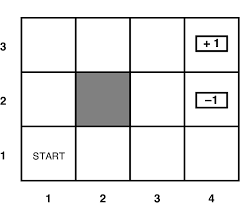

Objetivo llear a +1 y -1 equivale a perdida total, o sea es una casilla a evitar por completo. Supongamos que $\gamma = 0.9$ el cual es un coeficiente de descuenta, es una forma de penalizar un poco el objetivo y dar saltos con cierta ponderación.

Si nos ubicamos en la casilla (4,3) con por ejemplo una recompensa de $R=1$, se pueden calcular por ejemplo el paso a la casilla (3,3) dando un valor de $V=0.9$, iigualmente con (2,3) y su valor correspondiente $V=0.81$.

Para el caso de las siguientes casillas continuar con el cálculo de sus valores. Se puede observar que si nos basamos en recompensas, el objetivo es ir escalando las recompensas hasta llegar al objetivo +1 que corresponde a la casilla (4,3). Para generar otro camino se puede continuar de la misma forma, así, el objetivo explorar todos los caminos posibles. Bueno, esta es la base del algortimo Reinforcement Learning, sin embargo se realizan mejoras para conseguir el objetivo de una manera más precisa, pero lo importante es que se tenga la idea de como procesa el algoritmo una solución óptima.


**4. Algortimo Q-Learning**

Aprendizaje por refuerzo es aprender qué hacer (cómo asignar acciones a ciertas situaciones), con el fin de maximizar una señal de recompensa numérica. Al agente no se le especifica qué acciones tomar, como en algunas de las formas de aprendizaje de máquina, sino que debe descubrir cuáles acciones terminan en la mayor recompensa recibida. En los casos más interesantes y desafiantes, las acciones pueden afectar no sólo a la recompensa inmediata sino también a la siguiente situación y, por eso, todos los premios posteriores. Estas dos características, ensayo y error, y recompensa atrasada, son los dos rasgos distintivos más importantes de aprendizaje por refuerzo.
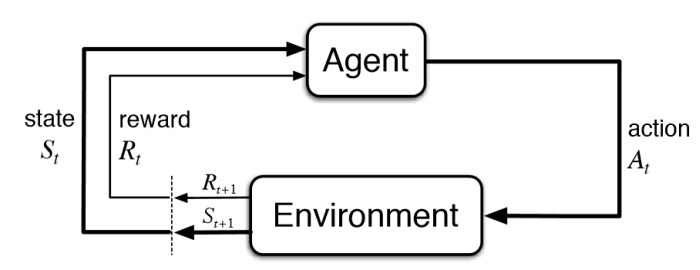

En la figura se puede observar el diagrama que describe el proceso general que
describe al aprendizaje por refuerzo. En dicho diagrama el agente y el ambiente
interactúan en una secuencia de intervalos de tiempo discretos $t=0,1,2...$, En cada paso el agente percibe que el ambiente se encuentra en un estado $E_t$ y toma una acción $A_t$ . En respuesta, el ambiente hace una transición estocástica a un nuevo estado $E_{t+1}$, y genera una recompensa asociada
$R_{t+1}$. El objetivo que busca el agente es seleccionar la acción de tal manera que maximice la recompensa esperada.

**4.1 El valor Q**

Para cada par de estado y acción $(e,a)$, vamos a asociar un valor numérico llamado $Q(e,a)$:

$Q: (e \in E, a \in A) \mapsto Q(e,a) \in \mathbb{R}$

Diremos que $Q(e,a)$ es el $Q$ de la acción $a$ levada a cabo en el estado $e$. Vamos a definir inicialmente la ecuación que define la el algortimo Q-Learning o de aprendizaje por refuerzo y vamos a ir intentando desglosarlo e ir implementandolo de acuerdo al problema propuesta en un inicio.

$Q_t(e_t,a_t) = Q_{t-1}(e_t,a_t) + \alpha TD_t(e_t,a_t)$

Donde $\alpha \in \mathbb{R}$ es la tasa de aprendizaje, que determina qué tan rápido va el aprendizaje de los valores $Q$ o qué tan grandes son las actualizaciones de los mismos. Su valor suele ser un número real elegido entre 0 y 1, como por ejemplo 0.01, 0.05, 0.1 o 0.5. Cuanto menor sea su valor, más pequeñas serán las actualizaciones de los valores Q y más larga será la ejecución del algoritmo de Q-Learning. Cuanto mayor sea su valor, mayores serán las actualizaciones de los valores Q y más rápido será el algoritmo de Q-Learning.

Con este punto de vista, los valores Q miden la acumulación de sorpresa o frustración asociada con el par de acciones y estados $(e_t, a_t)$. En el caso de recibir ganancia, el Sistema Inteligente se refuerza, y en el caso de recibir frustración, el sistema se debilita. Por lo tanto, queremos aprender los valores Q que le darán al sistema inteligente la máxima buena ganancia.

En consecuencia, la decisión de qué acción ejecutar depende principalmente del valor $Q(e_t, a_t)$. Si la acción $a_t$ ejecutada en el estado $e_t$ está asociada con un valor Q pequeño, el sistema tendría una menor tendencia a elegir la $a_t$.

Ahora podemos presentar la diferencia temporal, que básicamente es el corazón de Q-Learning. La diferencia temporal en el tiempo $t$, denotada por:

$TD_t(e_t,a_t) = R_i + \gamma \underset{a}{\max}(Q(e_{t+1},a)) - Q(e_t,a_t)$

Nuestro caso $R_i(e_t,a_t)$


Establezcamos los parámetros de nuestro modelo. Estos incluyen el factor de descuento  $γ$ y la tasa de aprendizaje $α$, que como vimos en la Sección 4.1, son los únicos parámetros del algoritmo Q-Learning que corresponden a la ecuación $Q(e_t,a_t)$ y $TD_t(e_t,a_t)$ vistas anteriormente.

In [14]:
# Configuración de los parámetros gamma y alfa para el Q-Learning
gamma = 0.75
alpha = 0.9
# Inicialización de los valores Q
Q = np.array(np.zeros([12,12]))

Éstos dos valores son variables y dependen mucho de la experiencia, por ahora dejemoslo en esos valores y posteriormente los modifican para obervar los comportamientos del algoritmo.

Luego, por supuesto, implementamos el proceso de Q-Learning, con un bucle for que llevará a cabo un total de 1000 iteraciones, repitiendo 1000 veces los pasos del proceso de Q-Learning que analizamos a fondo al final de la Sección 4.1:

In [15]:
# Implementación del proceso de Q-Learning
for i in range(1000):
    estado_actual = np.random.randint(0,12)
    accion_realizable = []
    for j in range(12):
        if R[estado_actual, j] > 0:
            accion_realizable.append(j)
    accion_actual = np.random.choice(accion_realizable)
    estado_siguiente = accion_actual
    Ri = R[estado_actual, accion_actual]
    TD = Ri + gamma*Q[estado_siguiente, np.argmax(Q[estado_siguiente,])]- Q[estado_actual, accion_actual]
    Q[estado_actual, accion_actual] = Q[estado_actual, accion_actual] + alpha*TD


Podemos echarle un vistazo ejecutando todo el código que hemos implementado hasta ahora e ingresando las siguientes dos instrucciones en la consola:

In [22]:
print("Q-Values:")
print(Q.astype(int))

Q-Values:
[[  0 171   0   0   0   0   0   0   0   0   0   0]
 [129   0 226   0   0 129   0   0   0   0   0   0]
 [  0 171   0   0   0   0 300   0   0   0   0   0]
 [  0   0   0   0   0   0   0 226   0   0   0   0]
 [  0   0   0   0   0   0   0   0  74   0   0   0]
 [  0 171   0   0   0   0   0   0   0  97   0   0]
 [  0   0 226   0   0   0 399 226   0   0   0   0]
 [  0   0   0 171   0   0 300   0   0   0   0 171]
 [  0   0   0   0  56   0   0   0   0  97   0   0]
 [  0   0   0   0   0 129   0   0  74   0 129   0]
 [  0   0   0   0   0   0   0   0   0  97   0 171]
 [  0   0   0   0   0   0   0 226   0   0 129   0]]


Probar para diferentes valores en la mariz de recompensa ...